In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import make_moons, make_s_curve

from Autoencoders import ConformalAutoencoder
from helper import load_optimizer_and_scheduler, save_optimizer_and_scheduler
from data import make_half_sphere
from metrics import evaluate_conformality

random_state = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
class Encoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Encoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
    
    def forward(self, x):
        return self.fc(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Decoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )
    
    def forward(self, z):
        return self.fc(z)

In [3]:
data, labels = make_s_curve(n_samples=3000, noise=0.05, random_state=random_state)
data = torch.tensor(data, dtype=torch.float32).to(device)
val_data, val_labels = make_s_curve(n_samples=1000, noise=0.05, random_state=random_state+1)
val_data = torch.tensor(val_data, dtype=torch.float32).to(device)

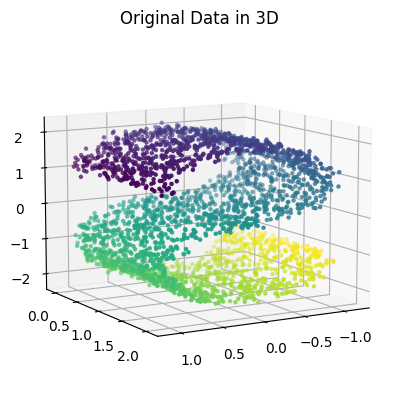

In [4]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0].cpu(), data[:, 1].cpu(), data[:, 2].cpu(), c=labels, s=5)
ax.set_title("Original Data in 3D")
ax.view_init(10, 60, 0)
plt.show()

In [5]:
# define model parameters
latent_dim = 2
input_dim = data.shape[1]
output_dim = data.shape[1]
batch_size = 128

train_dataloader = torch.utils.data.DataLoader(data, batch_size=batch_size, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=False)


dir_path = "models/conformal_autoencoder_trace_comp_swissroll"

In [6]:
lambda_isos = np.logspace(-3, 2, 9)
lambda_isos = np.concat([np.zeros(1), lambda_isos])

In [7]:
from metrics import conformality_trace_loss

In [8]:
import os

def modelpath(dir_path, lambda_iso, index):
    os.makedirs(dir_path, exist_ok=True)
    return f"{dir_path}/lambda_{lambda_iso:.3f}_model_{index+1}.pth"

In [9]:
num_epochs = 1000
# train same model multiple times to average results
num_models = 4

recon_errors = []
regularization_errors = []


for i, lambda_iso in enumerate(lambda_isos):
    recon_error = 0
    regularization = 0
    for j in range(num_models):
        print(f"Training model {j+1}/{num_models} with lambda_iso={lambda_iso:.3f}")
        
        encoder = Encoder(input_dim, latent_dim).to(device)
        decoder = Decoder(latent_dim, output_dim).to(device)
        model = ConformalAutoencoder(encoder, decoder, lambda_conf=lambda_iso).to(device)
        model.conformality_loss = conformality_trace_loss

        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)

        # Train the model
        model.train_model(train_dataloader, val_dataloader, batch_size=batch_size, epochs=num_epochs,
                          optimizer=optimizer, scheduler=scheduler, verbose=True)

        # Save the model and optimizer state
        model_path = modelpath(dir_path, lambda_iso, j)
        torch.save(model.state_dict(), model_path)
        print(f"Model {j+1}/{num_models} with lambda_iso={lambda_iso:.3f} trained and saved.")

        # evaluation
        model.eval()
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)
        
        recon_error += nn.MSELoss()(reconstruction, val_data).item()

        regularization += model.conformality_loss(model.decoder, encoded_data).item()
    
    recon_errors.append(recon_error/ num_models)
    regularization_errors.append(regularization/num_models)
    

Training model 1/4 with lambda_iso=0.000


/home/maxheise/anaconda3/envs/ML/lib/python3.13/site-packages/torch/autograd/graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch [100/1000], Loss: 0.00332708, Reconstruction Loss: 0.00332708, Conformal Loss: 0.35059401
Epoch [100/1000], Validation Loss: 0.00583489, Reconstruction Loss: 0.00583489, Conformal Loss: 0.34485239
Epoch [200/1000], Loss: 0.00173903, Reconstruction Loss: 0.00173903, Conformal Loss: 0.57039046
Epoch [200/1000], Validation Loss: 0.00344933, Reconstruction Loss: 0.00344933, Conformal Loss: 0.49463665
Epoch [300/1000], Loss: 0.00139766, Reconstruction Loss: 0.00139766, Conformal Loss: 0.52842921
Epoch [300/1000], Validation Loss: 0.00290966, Reconstruction Loss: 0.00290966, Conformal Loss: 0.79888737
Epoch [400/1000], Loss: 0.00125040, Reconstruction Loss: 0.00125040, Conformal Loss: 0.68753672
Epoch [400/1000], Validation Loss: 0.00259365, Reconstruction Loss: 0.00259365, Conformal Loss: 0.73870385
Epoch [500/1000], Loss: 0.00116826, Reconstruction Loss: 0.00116826, Conformal Loss: 1.03320301
Epoch [500/1000], Validation Loss: 0.00253169, Reconstruction Loss: 0.00253169, Conformal Lo

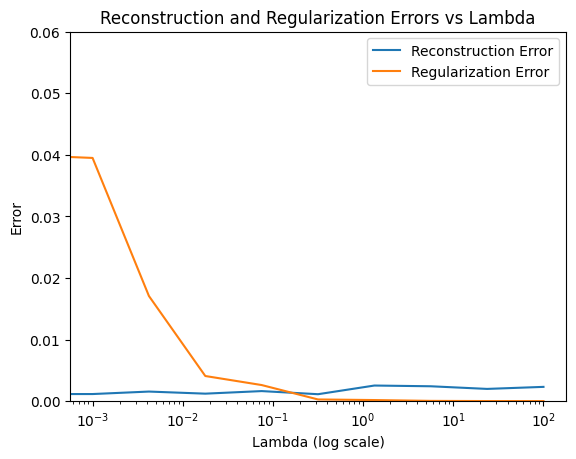

In [15]:
plt.plot(lambda_isos, recon_errors, label='Reconstruction Error')
plt.plot(lambda_isos, regularization_errors, label='Regularization Error')
plt.ylim(0, 0.06)
plt.xscale('log')
plt.xlabel('Lambda (log scale)')
plt.ylabel('Error')
plt.title('Reconstruction and Regularization Errors vs Lambda')
plt.legend()
plt.show()

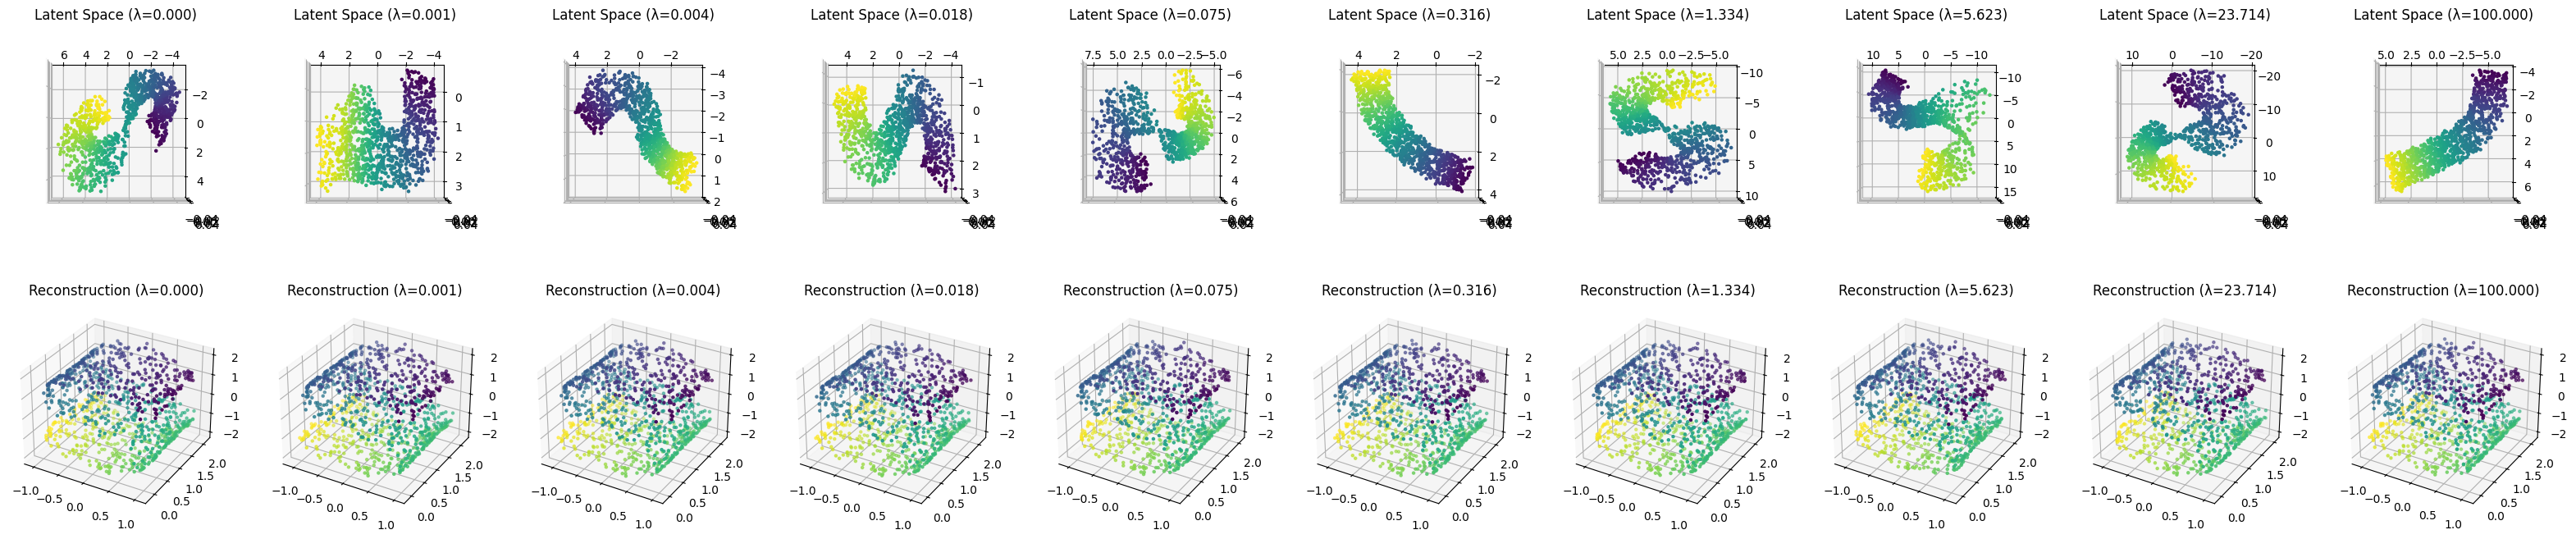

In [22]:
# plot samples and latent space at different lambdas
fig, axs = plt.subplots(2, 10, figsize=(40, 8), subplot_kw=dict(projection='3d'))
for i, lambda_iso in enumerate(lambda_isos):
    model_path = modelpath(dir_path, lambda_iso, 1)
    model = ConformalAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_conf=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))
    
    model.eval()
    with torch.no_grad():
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)

    axs[0, i].scatter(encoded_data[:, 0].cpu(), encoded_data[:, 1].cpu(), c=val_labels, s=5)
    axs[0, i].set_title(f'Latent Space (λ={lambda_iso:.3f})')
    axs[0, i].view_init(90, 90, 0)
    # axs[0, i].set_xticks([])
    # axs[0, i].set_yticks([])
    #plot 3d data
    axs[1, i].scatter(reconstruction[:, 0].cpu(), reconstruction[:, 1].cpu(), reconstruction[:, 2].cpu(), c=val_labels, s=5)
    axs[1, i].set_title(f'Reconstruction (λ={lambda_iso:.3f})')

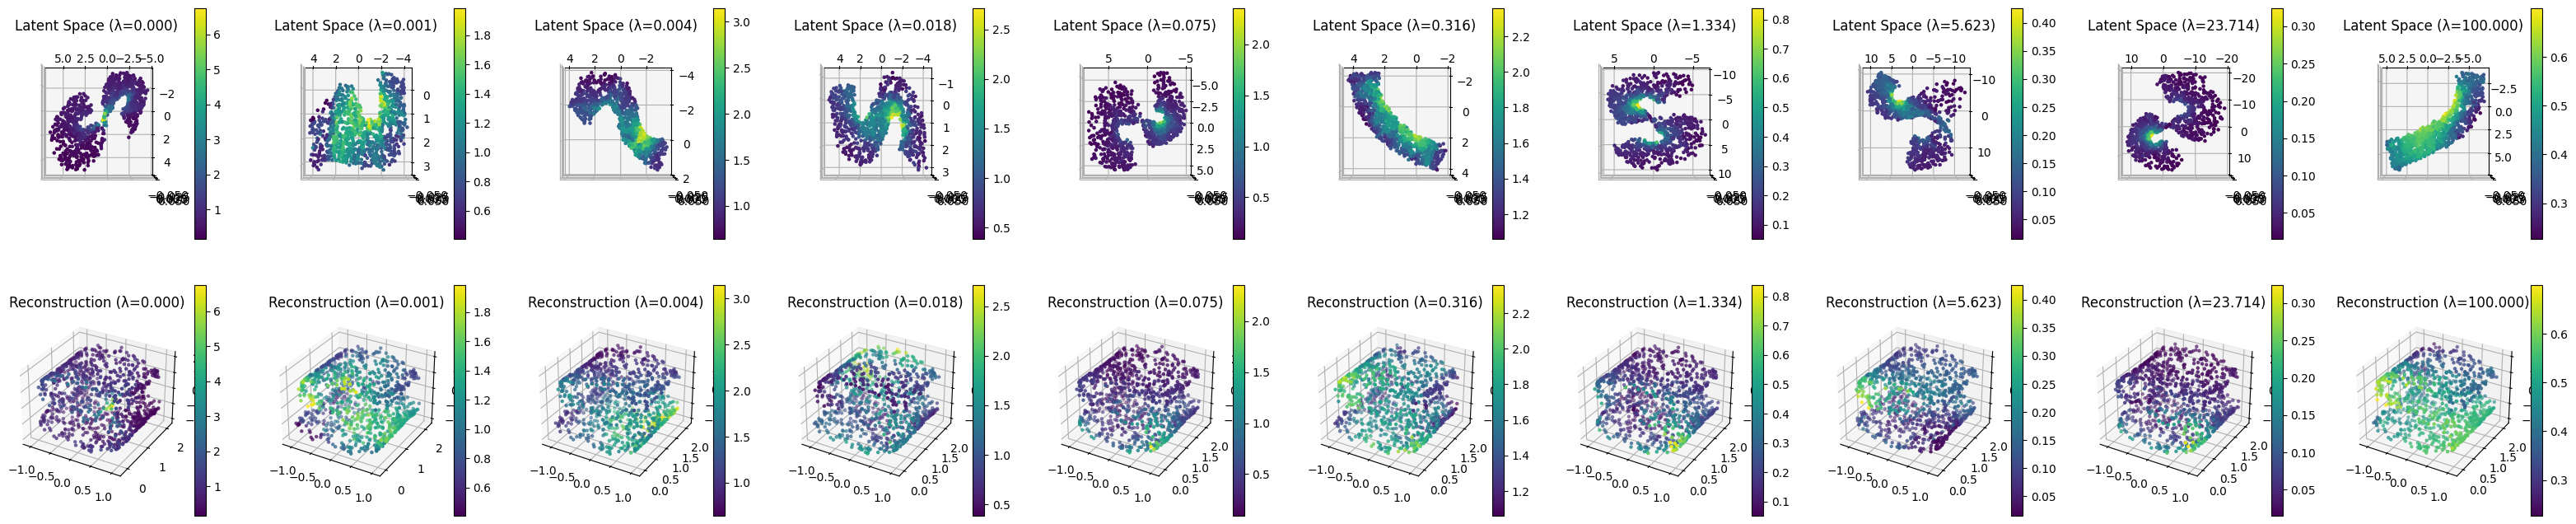

In [20]:
fig, axs = plt.subplots(2, 10, figsize=(40, 8), subplot_kw=dict(projection='3d'))
for i, lambda_iso in enumerate(lambda_isos):
    model_path = modelpath(dir_path, lambda_iso, 1)
    model = ConformalAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_conf=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))
    
    model.eval()
    with torch.no_grad():
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)

    trace_vals = np.zeros_like(encoded_data[:, 0].cpu())
    for j, z in enumerate(encoded_data):
        z = z.unsqueeze(0)  # Add batch dimension
        y = model.decode(z)  # Decode to get reconstruction
        y = y.squeeze(0)  # Remove batch dimension

        # Compute the Jacobian J of the decoder at point z
        J = torch.autograd.functional.jacobian(model.decode, z)[0,:,0,:]

        # Compute the trace of J^T J
        JtJ = J.T @ J
        trace_JtJ = torch.trace(JtJ)

        # Store the trace value as a label for the point
        trace_vals[j] = trace_JtJ.item() / JtJ.shape[0]  # Normalize by the number of dimensions

    p = axs[0, i].scatter(encoded_data[:, 0].cpu(), encoded_data[:, 1].cpu(), c=trace_vals, s=5)
    plt.colorbar(p)
    axs[0, i].set_title(f'Latent Space (λ={lambda_iso:.3f})')
    axs[0, i].view_init(90, 90, 0)
    # axs[0, i].set_xticks([])
    # axs[0, i].set_yticks([])
    #plot 3d data
    p = axs[1, i].scatter(reconstruction[:, 0].cpu(), reconstruction[:, 1].cpu(), reconstruction[:, 2].cpu(), c=trace_vals, s=5)
    plt.colorbar(p)
    axs[1, i].set_title(f'Reconstruction (λ={lambda_iso:.3f})')

In [9]:
statses = []
for i, lambda_iso in enumerate(lambda_isos):
    model_path = modelpath(dir_path, lambda_iso, 2)
    model = ConformalAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_conf=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))
    
    model.eval()
    with torch.no_grad():
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)

    statses.append(evaluate_conformality(model, data))

df = pd.DataFrame(statses, index=lambda_isos)
# styled_df = df.style.highlight_min(color='green').highlight_max(color='coral')

/home/maxheise/anaconda3/envs/ML/lib/python3.13/site-packages/torch/autograd/graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


torch.cuda.DoubleTensor
tensor([0.6213, 0.2042, 2.0084,  ..., 0.3635, 0.5670, 0.7102], device='cuda:0',
       dtype=torch.float64)
tensor([1., 1., 1.,  ..., 1., 1., 1.], device='cuda:0', dtype=torch.float64)
tensor([-1.0954, -1.6739,  0.4218,  ..., -1.3809, -0.6301, -0.3650],
       device='cuda:0', dtype=torch.float64)
tensor([-0.4759, -1.5889,  0.6973,  ..., -1.0119, -0.5673, -0.3423],
       device='cuda:0', dtype=torch.float64)
torch.cuda.DoubleTensor
tensor([1.7715, 1.4062, 1.2324,  ..., 1.4510, 0.7043, 1.5464], device='cuda:0',
       dtype=torch.float64)
tensor([1., 1., 1.,  ..., 1., 1., 1.], device='cuda:0', dtype=torch.float64)
tensor([ 0.5416,  0.1700,  0.0863,  ...,  0.3221, -0.4204,  0.2987],
       device='cuda:0', dtype=torch.float64)
tensor([ 0.5718,  0.3409,  0.2090,  ...,  0.3723, -0.3506,  0.4359],
       device='cuda:0', dtype=torch.float64)
torch.cuda.DoubleTensor
tensor([0.9276, 0.7444, 0.6094,  ..., 0.9543, 0.9126, 0.3739], device='cuda:0',
       dtype=torch.flo

In [11]:
styled_df = df.style \
    .background_gradient(subset=[
            'reconstruction_error',
            'diagonal_gini',
            'lambda_std',
            'lambda_std_normed',
            'off_diag_mean',
            'off_diag_norm',
            'off_diag_mean_normed',
            'off_diag_norm_normed',
            'jTj_minus_lambdaI_mean',
            'jTj_minus_lambdaI_norm',
            'jTj_minus_lambdaI_mean_normed',
            'jTj_minus_lambdaI_norm_normed',
            'determinant_vs_estimate_std',
            'log_determinant_vs_estimate_std',
            ], cmap='Reds') \
    .background_gradient(subset=[
            'log_determinant_vs_estimate_mean',
            ], cmap='Oranges') \
    .background_gradient(subset=[
        'determinant_vs_estimate_mean'
    ], cmap='Greens')\
    .background_gradient(subset=[
        'lambda_mean',
        'latent_std',
        'latent_std_max',
        'latent_std_min',
        'latent_norm',
    ], cmap='Blues')

styled_df

,reconstruction_error,diagonal_gini,lambda_mean,lambda_std,lambda_std_normed,off_diag_mean,off_diag_norm,off_diag_mean_normed,off_diag_norm_normed,jTj_minus_lambdaI_mean,jTj_minus_lambdaI_norm,jTj_minus_lambdaI_mean_normed,jTj_minus_lambdaI_norm_normed,determinant_vs_estimate_mean,determinant_vs_estimate_std,log_determinant_vs_estimate_mean,log_determinant_vs_estimate_std,latent_std,latent_std_max,latent_std_min,latent_norm
0.000000,0.000948,0.277798,1.417258,1.144002,0.807194,0.405512,1.146961,0.253400,0.716722,0.604869,1.384479,0.392299,0.886474,0.722813,0.192304,-0.380057,0.390123,1.953198,2.086779,1.819617,152.344009
0.001000,0.000954,0.238109,1.222465,0.527405,0.431428,0.188054,0.531898,0.176152,0.498234,0.339574,0.749563,0.295207,0.655957,0.858819,0.108247,-0.161132,0.138173,1.645620,2.185303,1.105937,139.307816
0.004217,0.000890,0.207862,1.014294,0.382698,0.377304,0.122800,0.347330,0.131317,0.371422,0.232447,0.521187,0.235249,0.528900,0.906389,0.093671,-0.104679,0.118633,1.728311,2.226545,1.230077,142.167770
0.017783,0.001217,0.236208,0.829870,0.593370,0.715015,0.084689,0.239536,0.138439,0.391563,0.172657,0.384715,0.256543,0.571820,0.871841,0.149987,-0.159711,0.241546,2.294206,2.465725,2.122687,184.840973
0.074989,0.001199,0.257506,0.430446,0.230095,0.534551,0.050036,0.141524,0.125118,0.353888,0.098294,0.218790,0.253871,0.566959,0.871724,0.163061,-0.169740,0.316695,2.769136,3.359898,2.178373,220.096283
0.316228,0.000892,0.082136,1.457557,0.414828,0.284605,0.046700,0.132087,0.039267,0.111063,0.092642,0.204006,0.080335,0.176166,0.984950,0.030654,-0.015686,0.032956,1.622105,1.689131,1.555080,150.157394
1.333521,0.001526,0.217597,0.221931,0.135127,0.608868,0.020293,0.057397,0.127622,0.360971,0.039003,0.087307,0.236421,0.526566,0.874325,0.171233,-0.163656,0.273412,4.285479,5.543509,3.027449,363.451721
5.623413,0.000854,0.052367,0.667032,0.177387,0.265934,0.016869,0.047712,0.029847,0.084421,0.032352,0.072374,0.056031,0.125441,0.992942,0.014896,-0.007200,0.015553,2.363419,2.623545,2.103292,205.257278
23.713737,0.001110,0.120322,0.267204,0.157134,0.588067,0.009481,0.026816,0.048555,0.137334,0.020554,0.045670,0.108716,0.240303,0.974618,0.045590,-0.026982,0.052536,3.409111,4.579728,2.238493,283.731232
100.000000,0.001733,0.207826,0.046539,0.037660,0.809217,0.003175,0.008980,0.096334,0.272475,0.006641,0.014712,0.200248,0.443193,0.922046,0.103166,-0.089823,0.145275,9.075134,9.967202,8.183067,724.045471


In [9]:
statses = []
for i, lambda_iso in enumerate(lambda_isos):
    model_path = modelpath(dir_path, lambda_iso, 2)
    model = ConformalAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_conf=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))
    
    model.eval()
    with torch.no_grad():
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)

    statses.append(evaluate_conformality(model, data))

df = pd.DataFrame(statses, index=lambda_isos)
# styled_df = df.style.highlight_min(color='green').highlight_max(color='coral')

/home/maxheise/anaconda3/envs/ML/lib/python3.13/site-packages/torch/autograd/graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


torch.cuda.DoubleTensor
tensor([0.6213, 0.2042, 2.0084,  ..., 0.3635, 0.5670, 0.7102], device='cuda:0',
       dtype=torch.float64)
tensor([1., 1., 1.,  ..., 1., 1., 1.], device='cuda:0', dtype=torch.float64)
tensor([-1.0954, -1.6739,  0.4218,  ..., -1.3809, -0.6301, -0.3650],
       device='cuda:0', dtype=torch.float64)
tensor([-0.4759, -1.5889,  0.6973,  ..., -1.0119, -0.5673, -0.3423],
       device='cuda:0', dtype=torch.float64)
torch.cuda.DoubleTensor
tensor([1.7715, 1.4062, 1.2324,  ..., 1.4510, 0.7043, 1.5464], device='cuda:0',
       dtype=torch.float64)
tensor([1., 1., 1.,  ..., 1., 1., 1.], device='cuda:0', dtype=torch.float64)
tensor([ 0.5416,  0.1700,  0.0863,  ...,  0.3221, -0.4204,  0.2987],
       device='cuda:0', dtype=torch.float64)
tensor([ 0.5718,  0.3409,  0.2090,  ...,  0.3723, -0.3506,  0.4359],
       device='cuda:0', dtype=torch.float64)
torch.cuda.DoubleTensor
tensor([0.9276, 0.7444, 0.6094,  ..., 0.9543, 0.9126, 0.3739], device='cuda:0',
       dtype=torch.flo